<a href="https://colab.research.google.com/github/SMN-SENAMHI/C3Smensual/blob/main/ECMWF_SUD_anomPrecTmaxTmin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Las siguientes gráficas corresponden a la base de datos de Copernicus en su versión actualizada, la cual permite mostrar el **pronóstico de los modelos globales** a nivel mensual para la anomalía de la **Temperatura máxima, mínima y precipitación**.  
Consultas: smn@senamhi.gob.pe, jllamocca@senamhi.gob.pe



In [ ]:
##Gráfica para todo Sudamérica

In [32]:
# Instalar librerías necesarias
!pip install xarray cartopy matplotlib pandas scipy geopandas

Archivo descargado exitosamente: flx.anom.ecmwf.nc


/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


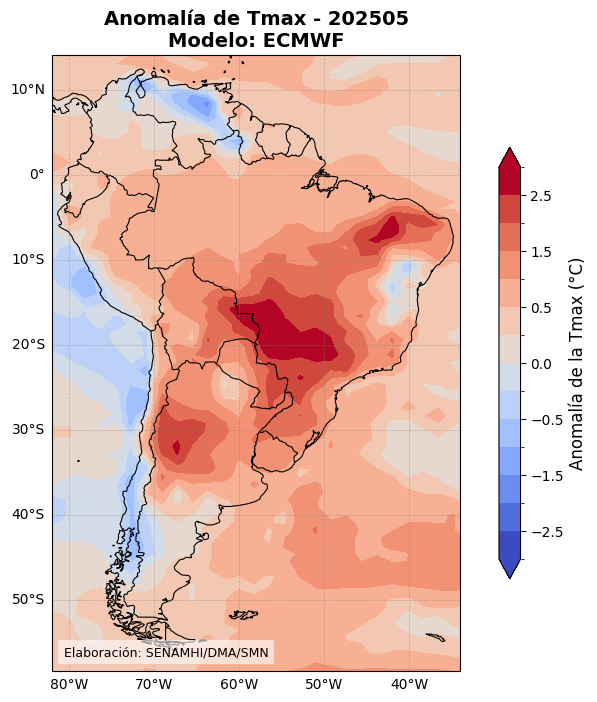

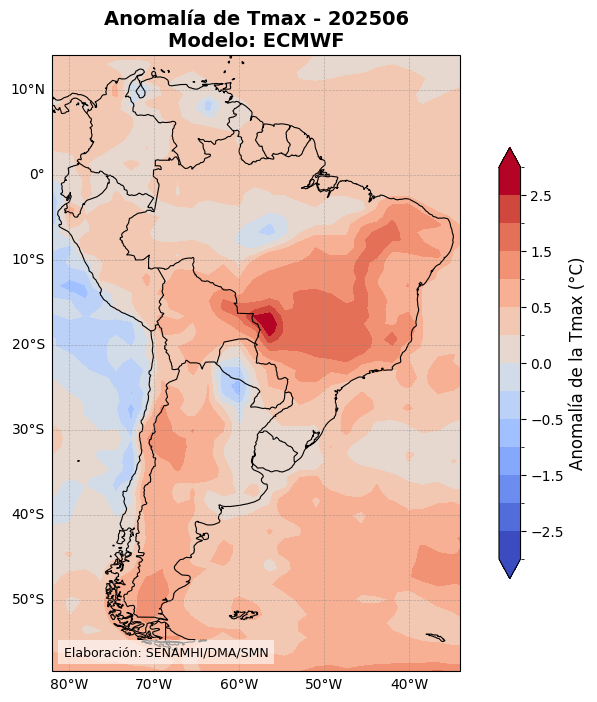

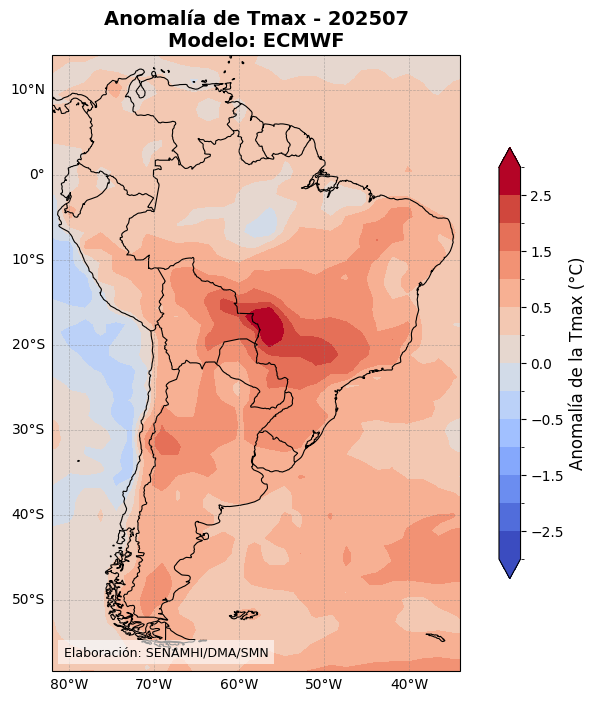

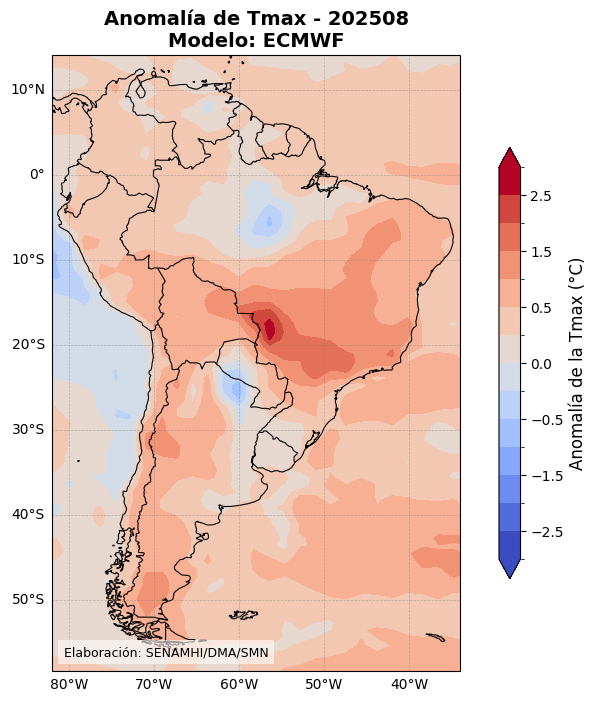

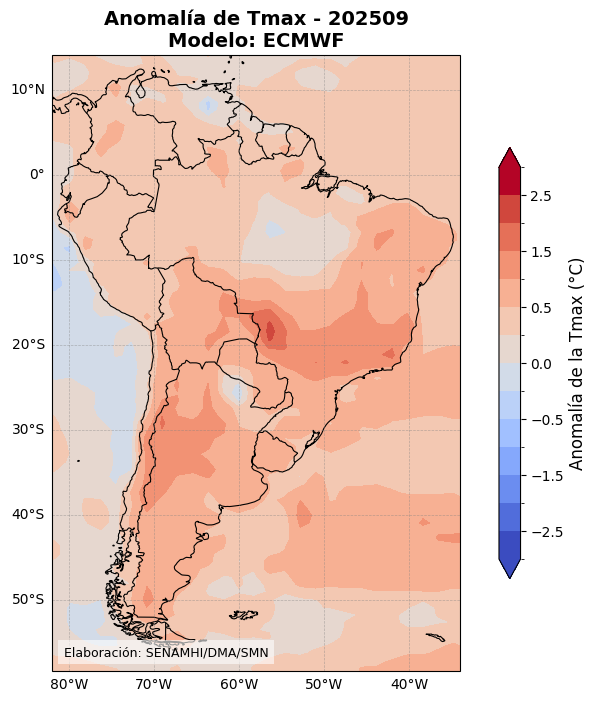

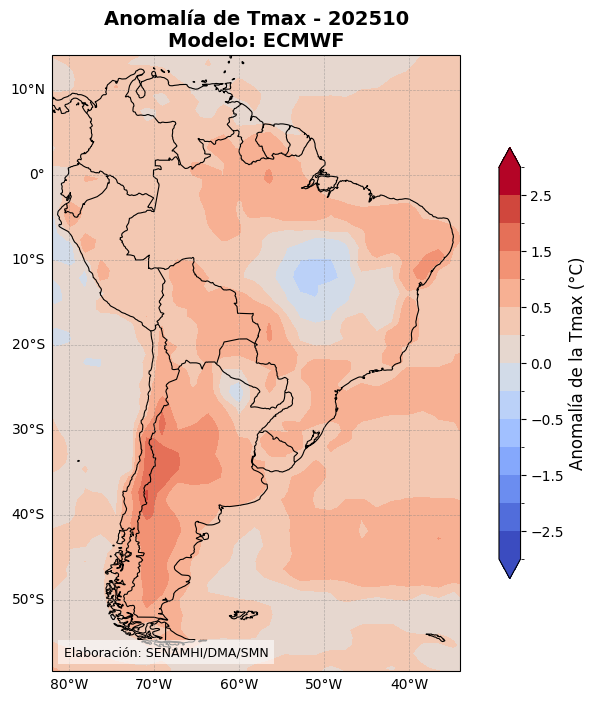

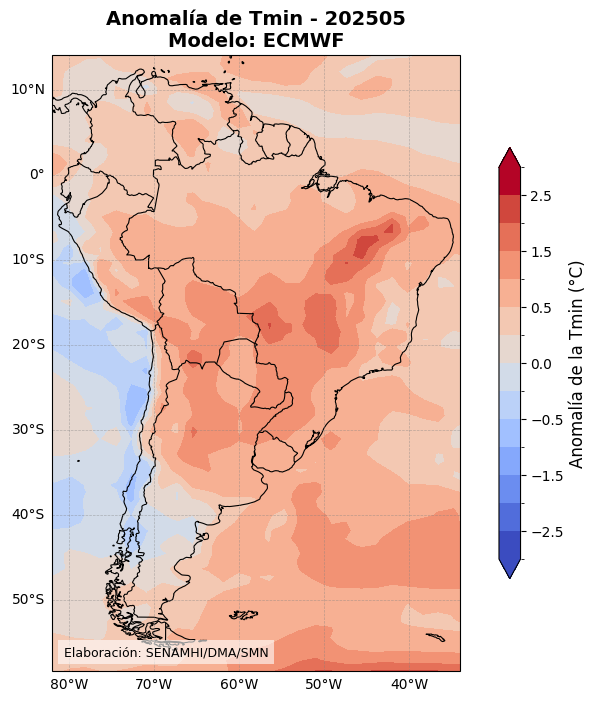

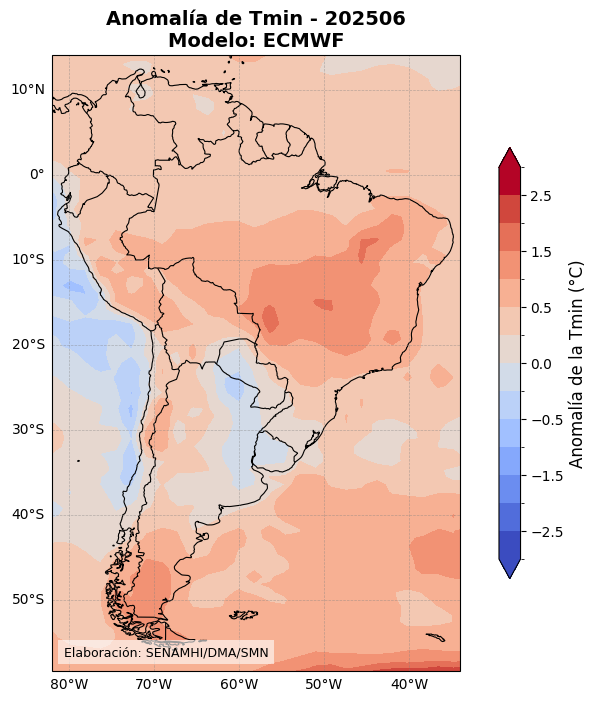

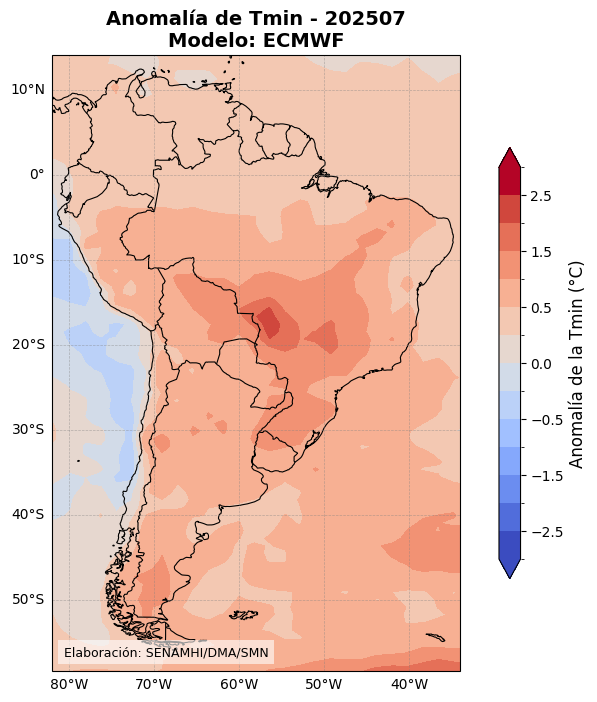

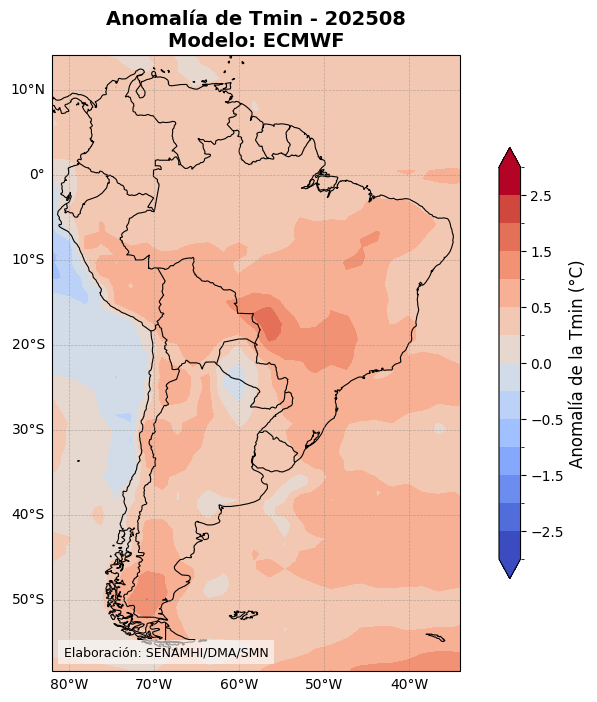

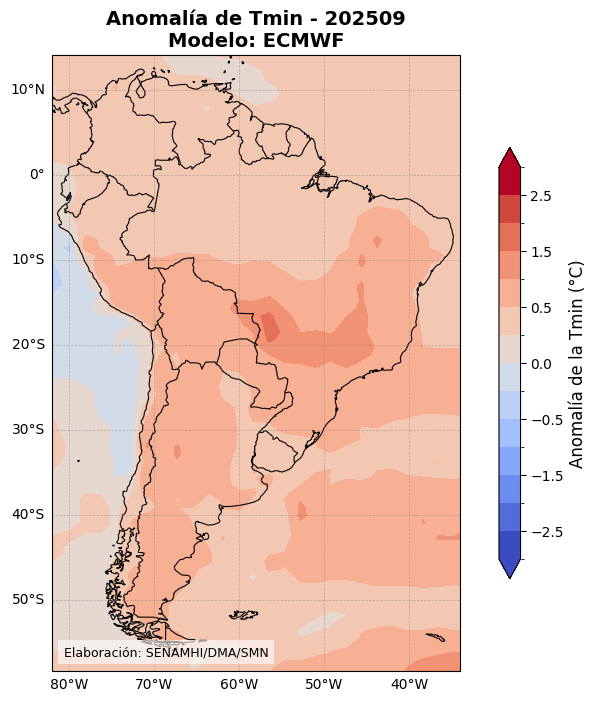

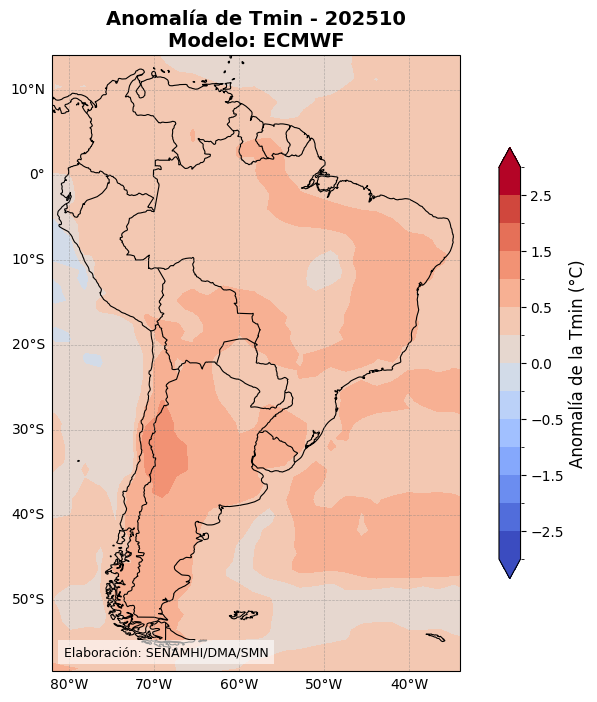

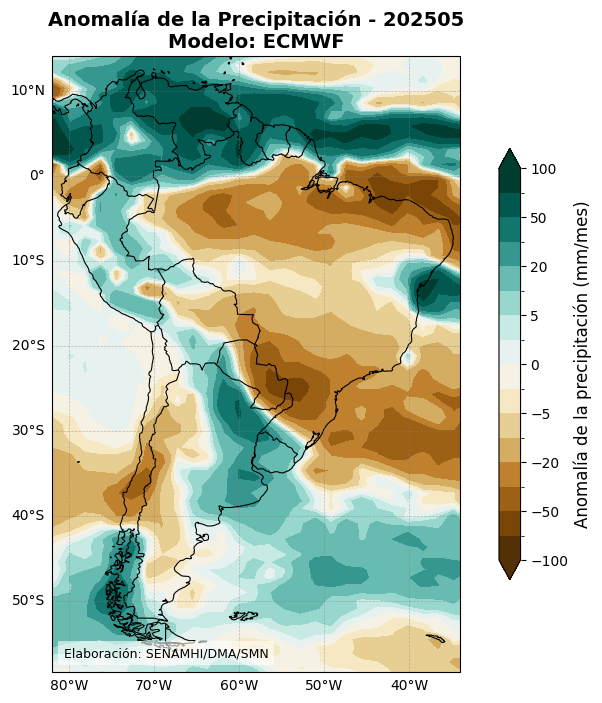

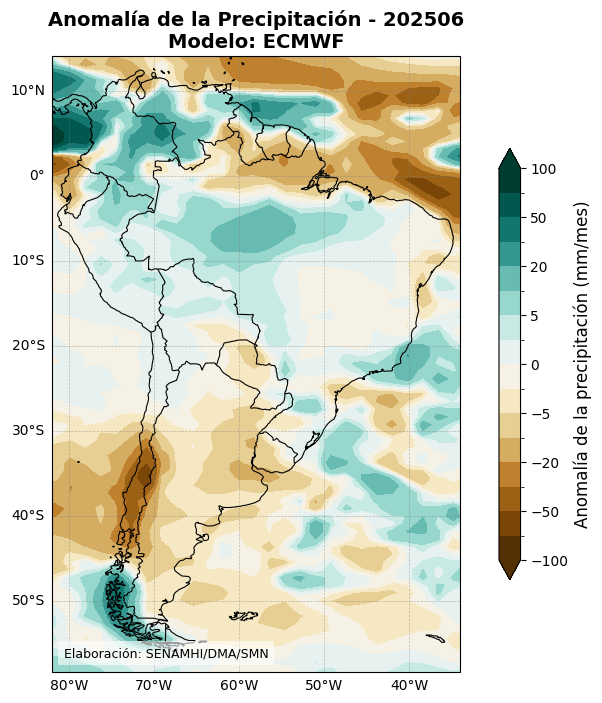

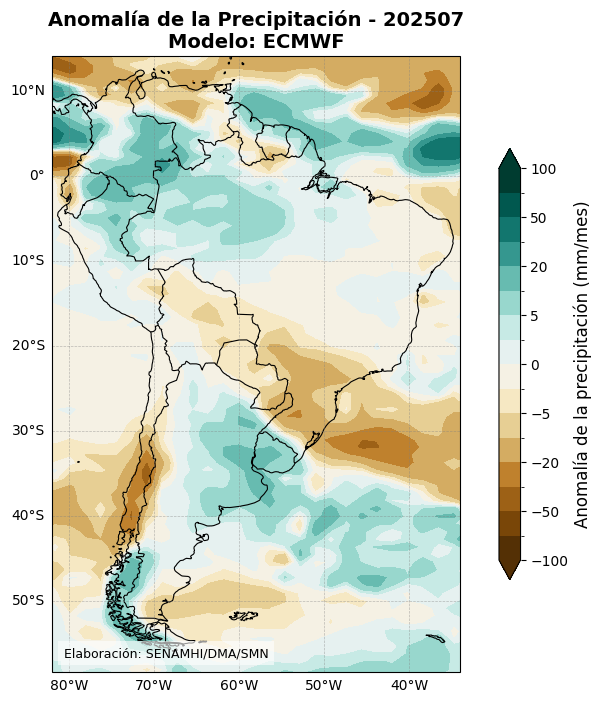

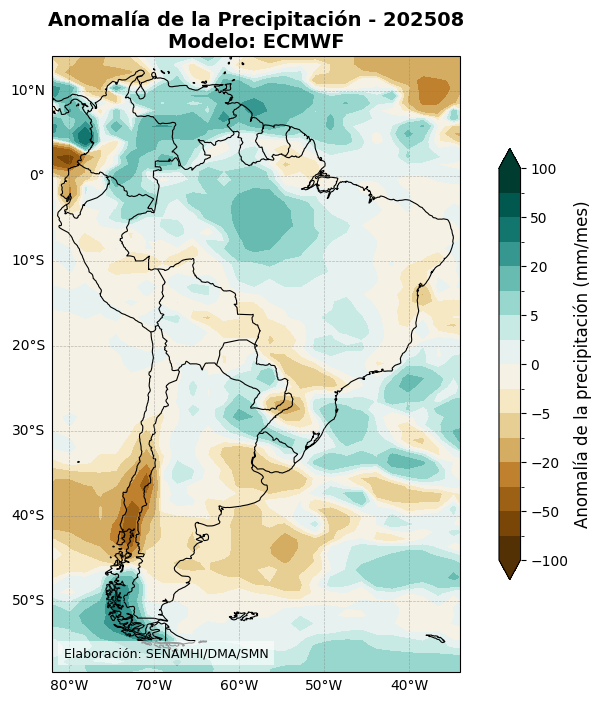

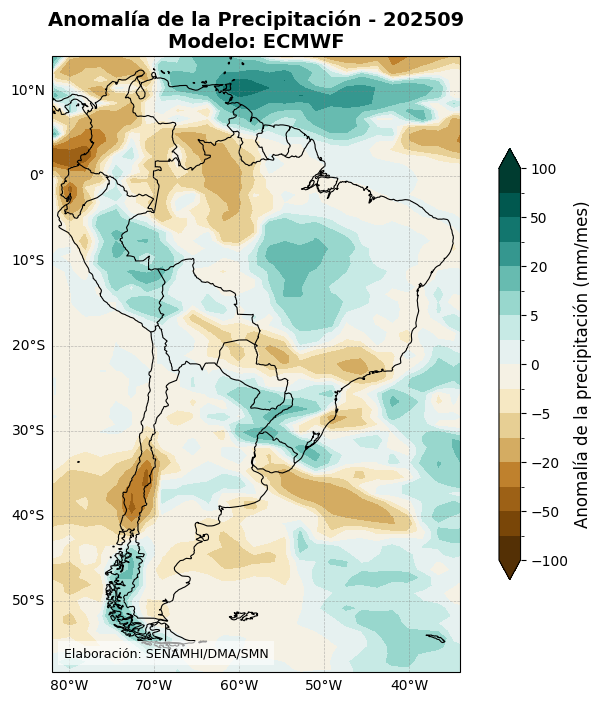

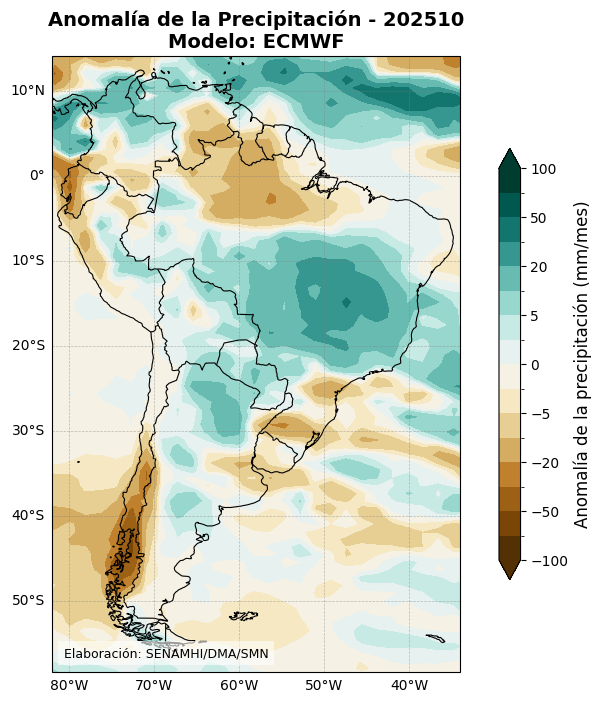

In [ ]:
import os
import requests
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from matplotlib.colors import BoundaryNorm
import pandas as pd
from scipy.interpolate import griddata
import matplotlib.ticker as mticker
import cartopy.feature as cfeature

# Función para descargar archivos desde una URL
def download_file(url, local_path):
    try:
        response = requests.get(url, stream=True)
        if response.status_code == 200:
            with open(local_path, "wb") as f:
                f.write(response.content)
            print(f"Archivo descargado exitosamente: {local_path}")
        else:
            print(f"Error al descargar el archivo: {response.status_code}")
    except Exception as e:
        print(f"Error durante la descarga: {e}")

# Descargar archivo NetCDF desde GitHub
data_url = "https://raw.githubusercontent.com/SMN-SENAMHI/C3Smensual/main/data/flx.anom.ecmwf.nc"
local_data_file = "flx.anom.ecmwf.nc"
download_file(data_url, local_data_file)

# Configurar extensión del mapa para Sudamérica
extent = [-82.0, -34.0, -56.0, 13.0]

# Cargar dataset ECMWF
ecmwf_ds = xr.open_dataset(local_data_file)
ref_time_ecmwf = ecmwf_ds['forecast_reference_time'].values[0]

# Definir función para interpolación cúbica
def cubic_interpolation(variable, lon, lat, new_lon, new_lat):
    lon2d, lat2d = np.meshgrid(lon, lat)
    points = np.array([lon2d.flatten(), lat2d.flatten()]).T
    values = variable.values.flatten()

    new_lon2d, new_lat2d = np.meshgrid(new_lon, new_lat)
    new_points = np.array([new_lon2d.flatten(), new_lat2d.flatten()]).T

    interpolated_values = griddata(points, values, new_points, method='cubic')
    return interpolated_values.reshape(new_lon2d.shape)

# Definir función para graficar variable
def plot_variable(variable, variable_name, cmap, bounds, norm, title_prefix, output_dir, filename_suffix, colorbar_label, modelo, ref_time):
    for fm in range(1, 7):
        if 'forecastMonth' in variable.coords:
            variable_fm = variable.sel(forecastMonth=fm)
        else:
            continue

        forecast_date = pd.to_datetime(ref_time) + pd.DateOffset(months=fm - 1)
        date_str = forecast_date.strftime('%Y%m')

        lon = variable_fm['longitude'].values
        lat = variable_fm['latitude'].values

        new_lon = np.linspace(lon.min(), lon.max(), 200)
        new_lat = np.linspace(lat.min(), lat.max(), 200)

        interpolated_values = cubic_interpolation(variable_fm, lon, lat, new_lon, new_lat)

        fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

        if not np.isnan(interpolated_values).all():
            plot = ax.contourf(new_lon, new_lat, interpolated_values, levels=bounds, cmap=cmap, norm=norm, extend='both', transform=ccrs.PlateCarree())

            ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.8)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
            ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='none', linewidth=0.6)

            ax.set_title(f'{title_prefix} - {date_str}\nModelo: {modelo.upper()}', fontsize=14, fontweight='bold')

            ax.set_extent(extent)

            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
            gl.xlocator = mticker.MultipleLocator(10)
            gl.ylocator = mticker.MultipleLocator(10)
            gl.top_labels = False
            gl.right_labels = False

            cbar = fig.colorbar(plot, ax=ax, orientation='vertical', shrink=0.7)
            cbar.set_label(colorbar_label, fontsize=12)

            ax.text(0.53, 0.02, 'Elaboración: SENAMHI/DMA/SMN',
                    horizontalalignment='right', verticalalignment='bottom',
                    transform=ax.transAxes, fontsize=9, color='black',
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

            filename = f'pre_{modelo}_{date_str}_{filename_suffix}_sudamerica.png'
            plt.savefig(os.path.join(output_dir, filename), dpi=300, bbox_inches='tight')
            plt.show()

        else:
            ax.set_title(f'Datos no disponibles - {date_str}')
            ax.set_extent(extent)
            plt.show()

        plt.close()

# Configurar el directorio de salida
output_dir = 'graphics'
os.makedirs(output_dir, exist_ok=True)

# Lista de modelos a procesar
modelos = ['ecmwf']

# Configurar información de las variables
variables_info = {
    'mx2t24a': {
        'cmap': 'coolwarm',
        'bounds': np.array([-3, -2.5, -2, -1.5, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 1.5, 2, 2.5, 3]),
        'title_prefix': 'Anomalía de Tmax',
        'filename_suffix': 'anomTempMax',
        'colorbar_label': 'Anomalía de la Tmax (°C)'
    },
    'mn2t24a': {
        'cmap': 'coolwarm',
        'bounds': np.array([-3, -2.5, -2, -1.5, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 1.5, 2, 2.5, 3]),
        'title_prefix': 'Anomalía de Tmin',
        'filename_suffix': 'anomTempMin',
        'colorbar_label': 'Anomalía de la Tmin (°C)'
    },
    'tpara': {
        'cmap': 'BrBG',
        'bounds': np.array([-100, -80, -50, -30, -20, -10, -5, -2.5, 0, 2.5, 5, 10, 20, 30, 50, 80, 100]),
        'title_prefix': 'Anomalía de la Precipitación',
        'filename_suffix': 'anomPrec',
        'colorbar_label': 'Anomalía de la precipitación (mm/mes)'
    }
}

# Procesar cada modelo
for modelo in modelos:
    ds = xr.open_dataset(local_data_file)

    # Convertir precipitación acumulada si está presente
    if 'tpara' in ds:
        segundos_por_mes = 30 * 24 * 3600
        ds['tpara'] = ds['tpara'] * 1000 * segundos_por_mes

    ref_time = ref_time_ecmwf

    for var, info in variables_info.items():
        if var in ds:
            variable = ds[var]
            norm = BoundaryNorm(boundaries=info['bounds'], ncolors=256)
            plot_variable(variable, var, info['cmap'], info['bounds'], norm, info['title_prefix'], output_dir, info['filename_suffix'], info['colorbar_label'], modelo, ref_time)


In [ ]:
#Países disponibles en el shapefile:NOMBRE
#Brasil
#Colombia
#Venezuela
#Argentina
#Bolivia
#Chile
#Costa Rica
#Ecuador
#French Guiana
#Guyana
#Oceano Pacifico
#Panamá
#Paraguay
#Perú
#Suriname
#Uruguay

✅ Actualizado: SUDAMERICA.shp
✅ Actualizado: SUDAMERICA.dbf
✅ Actualizado: SUDAMERICA.shx
✅ Actualizado: flx.anom.ecmwf.nc

📌 Países disponibles en el shapefile:
    OBJECTID           NOMBRE
0          1           Brasil
1          2         Colombia
2          3        Venezuela
3          4        Argentina
4          5          Bolivia
5          6            Chile
6          7       Costa Rica
7          8          Ecuador
8          9    French Guiana
9         10           Guyana
10        11  Oceano Pacifico
11        12           Panamá
12        13         Paraguay
13        14             Perú
14        15         Suriname
15        16          Uruguay

📌 País seleccionado: Argentina
Bounds: [-73.58537629 -55.05478161 -53.65138475 -21.78396425]


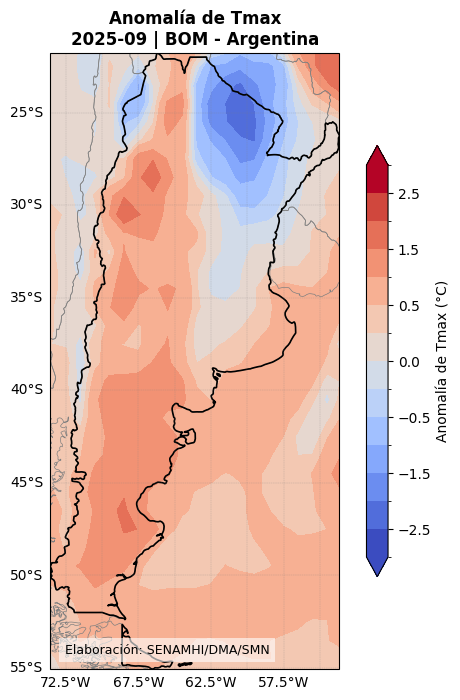

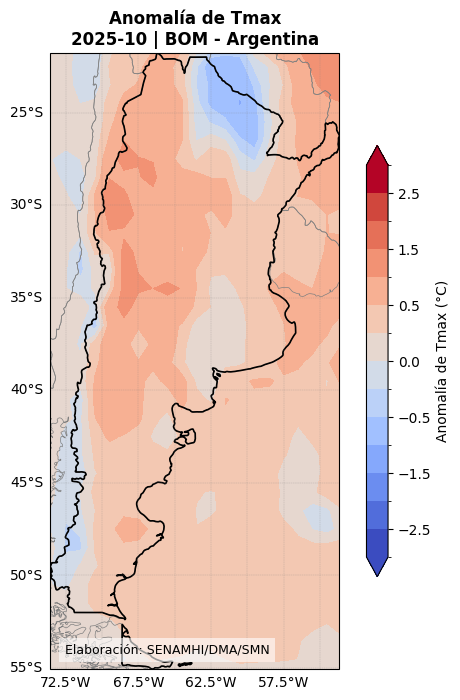

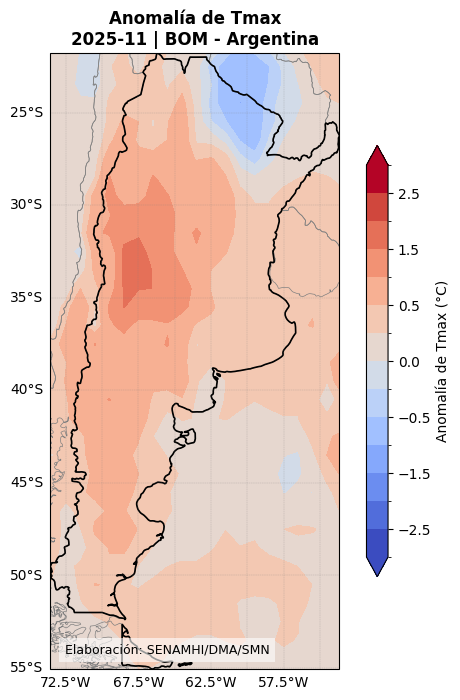

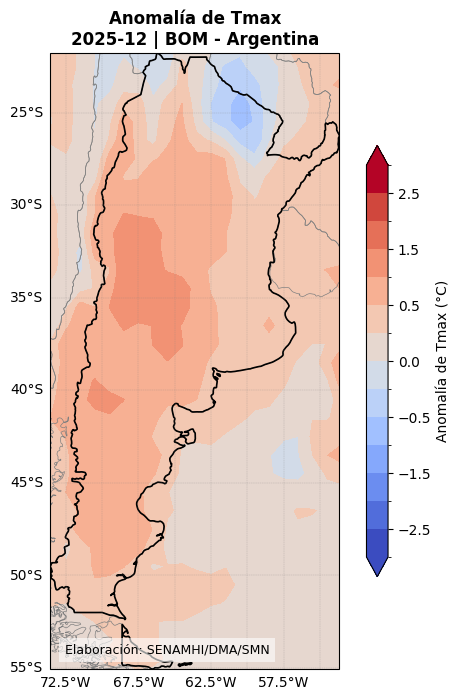

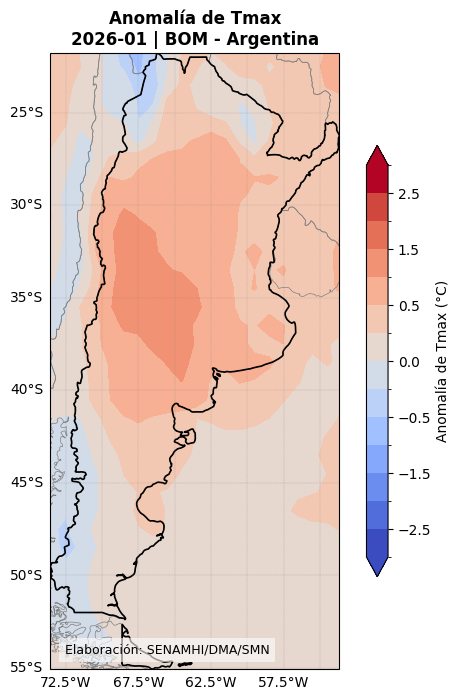

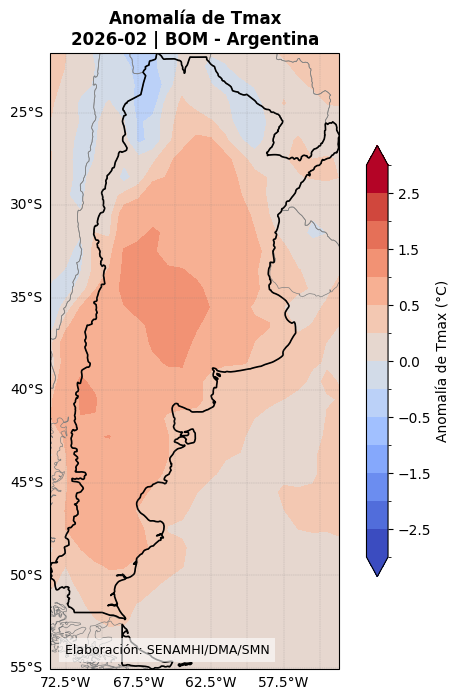

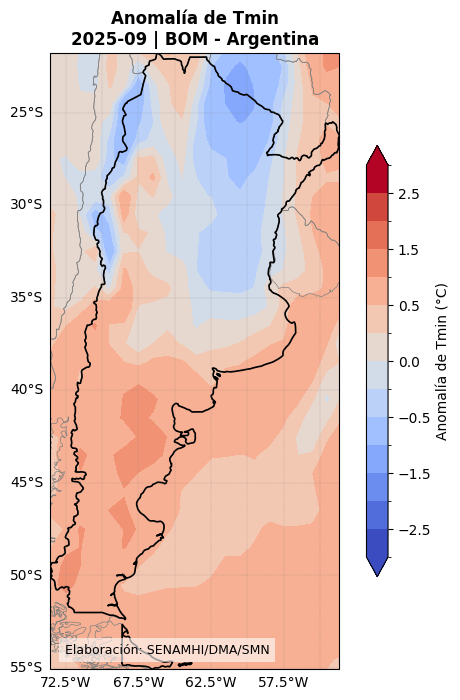

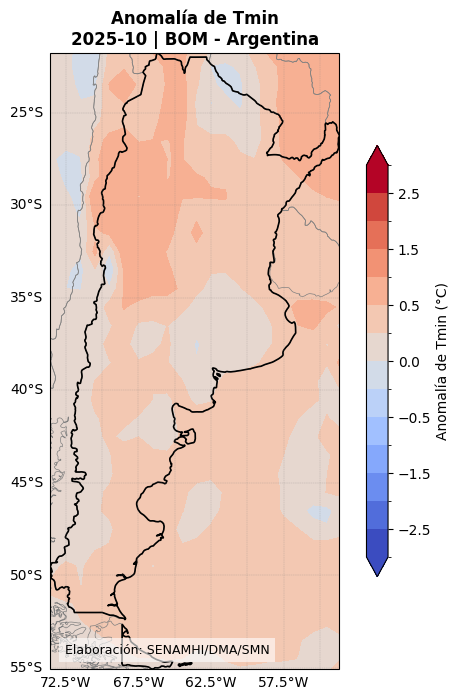

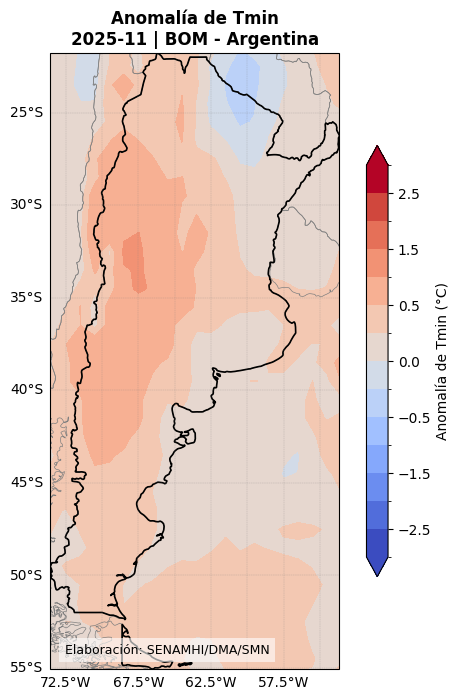

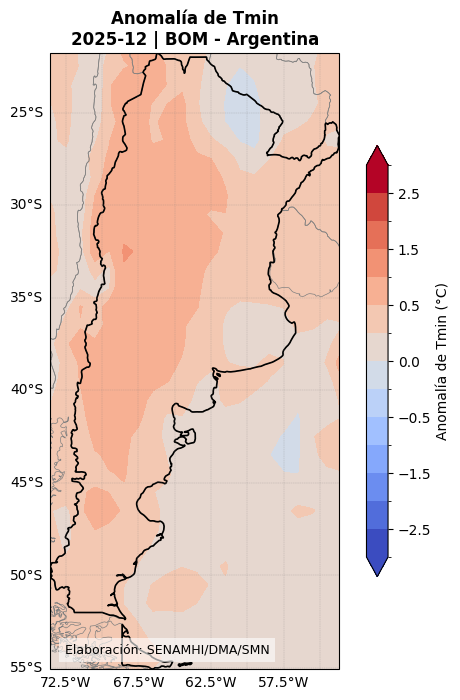

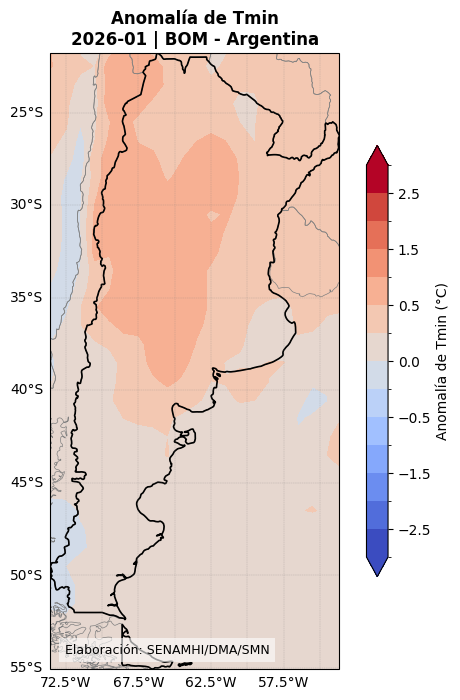

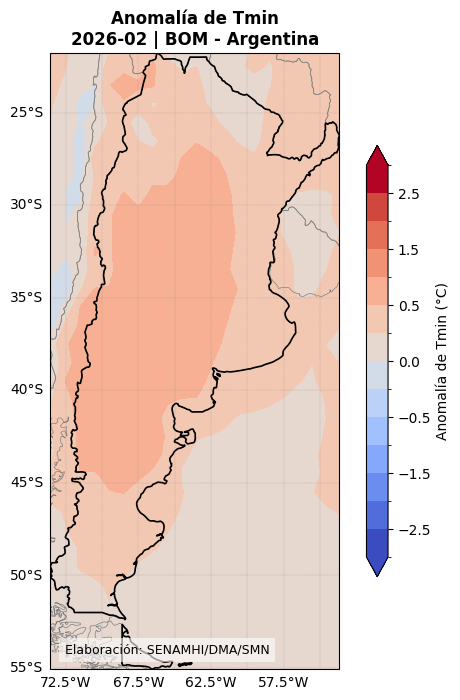

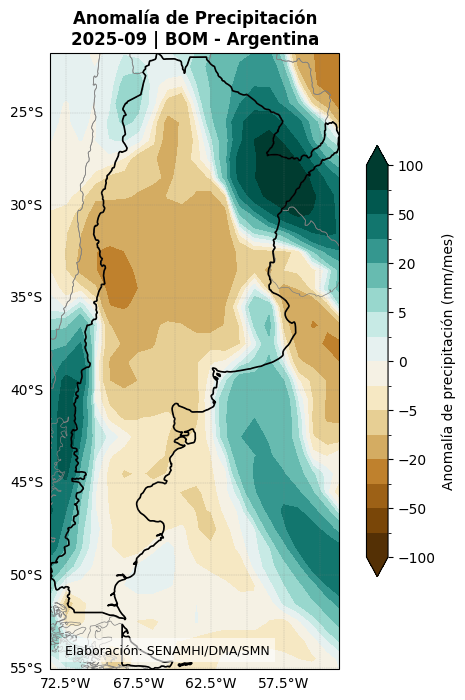

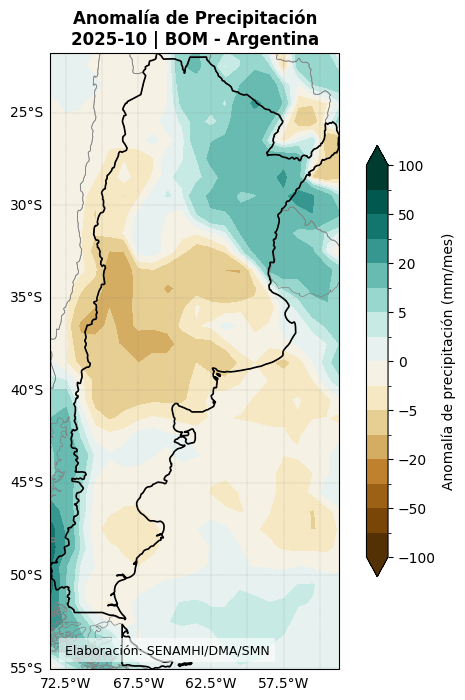

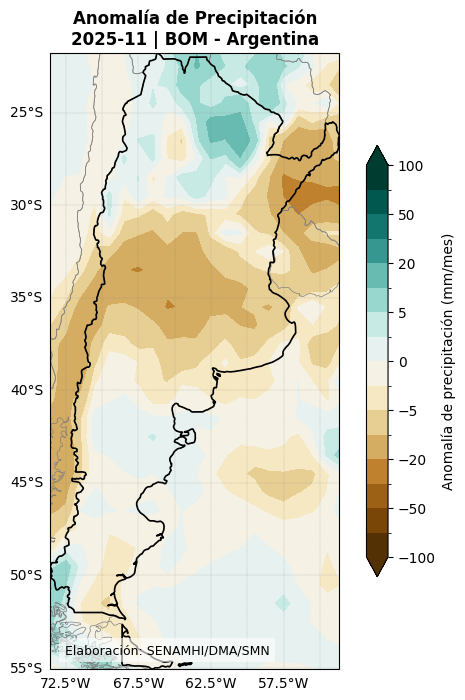

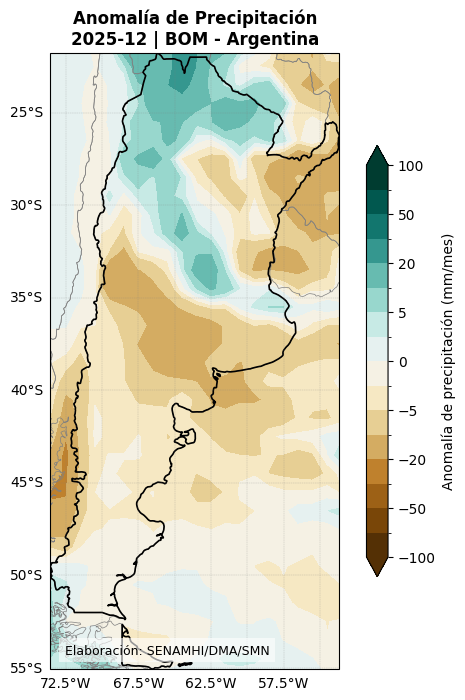

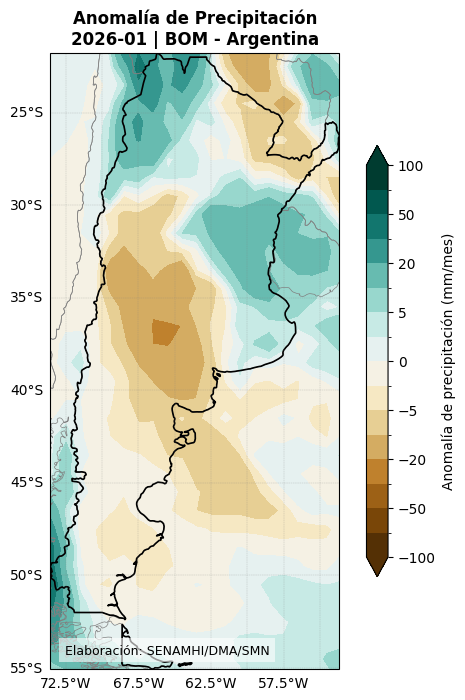

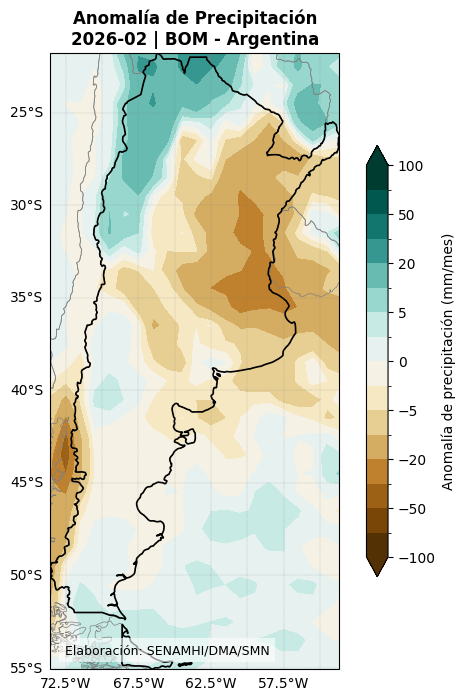

In [40]:
import os
import requests
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from matplotlib.colors import BoundaryNorm
import pandas as pd
import geopandas as gpd

# =========================
# CONFIGURACIÓN INICIAL
# =========================
pais_seleccion = "Argentina"   # Cambia aquí el país que quieras
modelo = "BOM"

# =========================
# FUNCIÓN DESCARGA (forzar actualización siempre)
# =========================
def download_file(url, local_path):
    r = requests.get(url, stream=True)
    if r.status_code == 200:
        with open(local_path, "wb") as f:
            f.write(r.content)
        print(f"✅ Actualizado: {local_path}")
    else:
        print(f"⚠ Error {r.status_code} al descargar {url}")

# =========================
# DESCARGAR SHAPEFILE
# =========================
shapefiles = {
    "SUDAMERICA.shp": "https://raw.githubusercontent.com/SMN-SENAMHI/Materiales/main/shape/SUDAMERICA.shp",
    "SUDAMERICA.dbf": "https://raw.githubusercontent.com/SMN-SENAMHI/Materiales/main/shape/SUDAMERICA.dbf",
    "SUDAMERICA.shx": "https://raw.githubusercontent.com/SMN-SENAMHI/Materiales/main/shape/SUDAMERICA.shx",
}
for name, url in shapefiles.items():
    download_file(url, name)

# =========================
# DESCARGAR NETCDF
# =========================
data_url = "https://raw.githubusercontent.com/SMN-SENAMHI/C3Smensual/main/data/flx.anom.ecmwf.nc"
local_nc = "flx.anom.ecmwf.nc"
download_file(data_url, local_nc)

# =========================
# CARGAR SHAPEFILE Y FIJAR CRS
# =========================
gdf = gpd.read_file("SUDAMERICA.shp")

# ⚠️ CRS correcto: WGS84 / UTM zona 18S → reproyectar a lat/lon
gdf = gdf.set_crs("EPSG:32718").to_crs("EPSG:4326")

# =========================
# NORMALIZAR NOMBRES DE PAÍSES
# =========================
gdf["NOMBRE"] = gdf["NOMBRE"].replace({
    "PerÃº": "Perú",
    "Panama": "Panamá"
})

print("\n📌 Países disponibles en el shapefile:")
print(gdf[["OBJECTID", "NOMBRE"]])

# Selección robusta por nombre
gdf_pais = gdf[gdf["NOMBRE"].str.upper() == pais_seleccion.upper()]
if gdf_pais.empty:
    raise ValueError(f"⚠ No se encontró el país '{pais_seleccion}' en el shapefile.")

print(f"\n📌 País seleccionado: {pais_seleccion}")
print("Bounds:", gdf_pais.total_bounds)

# =========================
# CARGAR ECMWF
# =========================
ds = xr.open_dataset(local_nc)

# Conversión de precipitación acumulada (de m/s a mm/mes)
if "tpara" in ds:
    segundos_mes = 30 * 24 * 3600
    ds["tpara"] = ds["tpara"] * 1000 * segundos_mes

# Corregir longitudes a -180 → 180
ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180))
ds = ds.sortby("longitude")

ref_time = pd.to_datetime(ds["forecast_reference_time"].values[0])

# =========================
# CONFIGURAR VARIABLES
# =========================
variables_info = {
    "mx2t24a": {
        "cmap": "coolwarm",
        'bounds': np.array([-3, -2.5, -2, -1.5, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 1.5, 2, 2.5, 3]),
        "title": "Anomalía de Tmax",
        "label": "Anomalía de Tmax (°C)"
    },
    "mn2t24a": {
        "cmap": "coolwarm",
        'bounds': np.array([-3, -2.5, -2, -1.5, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 1.5, 2, 2.5, 3]),
        "title": "Anomalía de Tmin",
        "label": "Anomalía de Tmin (°C)"
    },
    "tpara": {
        "cmap": "BrBG",
        "bounds": [-100, -80, -50, -30, -20, -10, -5, -2.5,
                   0, 2.5, 5, 10, 20, 30, 50, 80, 100],
        "title": "Anomalía de Precipitación",
        "label": "Anomalía de precipitación (mm/mes)"
    }
}

# =========================
# FUNCIÓN DE PLOT
# =========================
def plot_variable(var, info, fm, ref_time, gdf, gdf_pais, pais_nombre):
    variable_fm = ds[var].sel(forecastMonth=fm)

    lon = ds["longitude"].values
    lat = ds["latitude"].values
    values = variable_fm.values.squeeze()

    # Bounds del país
    minx, miny, maxx, maxy = gdf_pais.total_bounds

    fig, ax = plt.subplots(figsize=(7, 8), subplot_kw={"projection": ccrs.PlateCarree()})

    norm = BoundaryNorm(info["bounds"], ncolors=256)
    cs = ax.contourf(lon, lat, values, levels=info["bounds"],
                     cmap=info["cmap"], norm=norm, extend="both")

    # Fronteras
    gdf.boundary.plot(ax=ax, color="gray", linewidth=0.5, transform=ccrs.PlateCarree())
    gdf_pais.boundary.plot(ax=ax, color="black", linewidth=1.2, transform=ccrs.PlateCarree())

    # Extensión al país
    ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())

    # Grid con etiquetas automáticas
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    # Título
    fecha = ref_time + pd.DateOffset(months=fm-1)
    ax.set_title(f"{info['title']}\n{fecha.strftime('%Y-%m')} | {modelo} - {pais_nombre}",
                 fontsize=12, fontweight="bold")

    # Colorbar
    cbar = fig.colorbar(cs, ax=ax, orientation="vertical", shrink=0.7)
    cbar.set_label(info["label"])

    # ➕ Créditos SENAMHI
    ax.text(
        0.05, 0.02, 'Elaboración: SENAMHI/DMA/SMN',
        horizontalalignment='left', verticalalignment='bottom',
        transform=ax.transAxes, fontsize=9, color='black',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
    )

    plt.show()

# =========================
# LOOP PRINCIPAL
# =========================
for var, info in variables_info.items():
    for fm in ds["forecastMonth"].values:
        plot_variable(var, info, fm, ref_time, gdf, gdf_pais, pais_seleccion)
